In [1]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

# Set seed, relevant for visualizations
rng = np.random.default_rng(seed=10)

# Load data

In [2]:
# Load IOM DTM Somalia dataset Feb-Oct 2025
df_dtm = pd.read_excel('data/IOM_DTM_ETT_SOM_Tracker_sinceFeb2025_w19.xlsx')    # TODO: load only necesary columns
df_dtm.head(3)

,Date of Assessment,Region Name,District Name,OCHA Region Pcode,OCHA District Pcode,Operational Zone,Catchment,Settlement Name,Settlement ID,Location Type,...,Needs - Temporary Learning Classes,Needs - CCCM Site improvement,Needs - CCCM Complaints and Feedback Mechanism,Needs - CCCM Site Decongestion,Needs - CCCM Plot Allocation,Data Collection Week,Origin_Destination,Origin_Region_country,Origin_District_country,Reason of Displacement
0,2025-06-16,Galgaduud,Cabudwaaq,SO19,SO1902,OPZ 211,NaN,Canjiidle,DTM-SO1902-12769,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OC,Ethiopia,Ethiopia,Drought
1,2025-06-14,Bay,Baidoa,SO24,SO2401,OPZ 179,CA02,Wadajir 6 Jinaay,DTM-SO2401-11287,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Bakool,Waajid,Drought
2,2025-06-14,Galgaduud,Dhuusamarreeb,SO19,SO1901,OPZ 226,NaN,Dalab,DTM-SO1901-6596,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Hiraan,Bulo Burto,Drought


In [4]:
sorted(df_dtm['Data Collection Week'].unique())

['Week 01 (8-12 February, 2025)',
 'Week 02 (15-19 February, 2025)',
 'Week 03 (22-26 February, 2025)',
 'Week 04 (1-5 March, 2025)',
 'Week 05 (8-12 March, 2025)',
 'Week 06 (15-19 March, 2025)',
 'Week 07 (22-26 March, 2025)',
 'Week 08 (29 March - 2 April, 2025)',
 'Week 09 (5 - 9 April, 2025)',
 'Week 10 (12 - 16 April, 2025)',
 'Week 11 (19 - 23 April, 2025)',
 'Week 12 (26 - 30 April, 2025)',
 'Week 13 (3 - 7 May, 2025)',
 'Week 14 (10 - 14 May, 2025)',
 'Week 15 (17 - 21 May, 2025)',
 'Week 16 (24 - 28 May, 2025)',
 'Week 17 (31 May - 04 June, 2025)',
 'Week 18 (8 - 11 June, 2025)',
 'Week 19 (14 - 18 June, 2025)']

In [5]:
# Load GADM dataset
gdf_gadm = gpd.read_file('data/gadm41_SOM_2.json.zip')
gdf_gadm = gdf_gadm.to_crs('epsg:20539') # centroids are obtained with more accuracy using a projected CRS
gdf_gadm['centroid'] = gdf_gadm.centroid

gdf_gadm.head(3)

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,centroid
0,SOM.1.1_1,SOM,Somalia,SOM.1_1,Awdal,NA,Baki,NA,NA,District,District,NA,SO.AW.BA,"MULTIPOLYGON (((-258918.643 1178983.263, -2583...",POINT (-297818.987 1143950.621)
1,SOM.1.2_1,SOM,Somalia,SOM.1_1,Awdal,NA,Boorama,Boramo|Borama,NA,District,District,NA,SO.AW.BO,"MULTIPOLYGON (((-346944.62 1076389.937, -34730...",POINT (-360144.965 1134011.013)
2,SOM.1.3_1,SOM,Somalia,SOM.1_1,Awdal,NA,Lughaya,Lughaye,NA,District,District,NA,SO.AW.LU,"MULTIPOLYGON (((-258918.643 1178983.263, -3287...",POINT (-313798.554 1184798.15)


# Districts

In [6]:
# In using 'Somalia District of Origin' we ignore Ethiopia and Other, but have to remove NaNs
origin_districts = df_dtm['Somalia District of Origin'][df_dtm['Somalia District of Origin'].notna()].unique()  
origin_districts

array(['Waajid', 'Bulo Burto', 'Diinsoor', 'Xudur', 'Garoowe',
       'Adan Yabaal', 'Balcad', 'Saakow', 'Qansax Dheere', 'Qoryooley',
       'Belet Weyne', 'Baardheere', 'Baidoa', "Bu'Aale", 'Jalalaqsi',
       'Jamaame', 'Gaalkacyo', 'Afgooye', 'Jowhar', 'Ceel Dheer',
       'Cabudwaaq', 'Luuq', 'Kismaayo', 'Rab Dhuure', 'Kurtunwaarey',
       'Cadale', 'Buur Hakaba', 'Badhaadhe', 'Ceel Barde', 'Ceel Buur',
       'Garbahaarey', 'Tayeeglow', 'Afmadow', 'Dhuusamarreeb',
       'Belet Xaawo', 'Dharkenley', 'Hobyo', 'Marka', 'Taleex', 'Jilib',
       'Ceel Waaq', 'Bossaso', 'Wanla Weyn', 'Baraawe', 'Doolow',
       'Sablaale', 'Hodan', 'Xarardheere', 'Wardhigley', 'Hamar Jabjab',
       'Jariiban', 'Ceerigaabo', 'Dayniile', 'Galdogob', 'Kahda', 'Eyl',
       'Shangaani', 'Hawl Wadaag', 'Qardho', 'Cadaado', 'Laasqoray',
       'Burtinle', 'Laas Caanood', 'Huriwaa', 'Qandala', 'Zeylac',
       'Waaberi', 'Caluula', 'Shibis', 'Wadajir (Medina)', 'Caynabo'],
      dtype=object)

In [7]:
destination_districts = df_dtm['District Name'].unique()
destination_districts

array(['Cabudwaaq', 'Baidoa', 'Dhuusamarreeb', 'Diinsoor', 'Xudur',
       'Garoowe', 'Hodan', 'Baardheere', 'Dayniile', "Bu'Aale",
       'Qansax Dheere', 'Balcad', 'Belet Weyne', 'Kismaayo', 'Gaalkacyo',
       'Waajid', 'Afgooye', 'Jowhar', 'Doolow', 'Bulo Burto', 'Luuq',
       'Kahda', 'Afmadow', 'Belet Xaawo', 'Jamaame'], dtype=object)

In [8]:
set(destination_districts) - set(origin_districts)

set()

There are no destination districts that are not also origin districts (origins are superset)

In [9]:
districts_dtm = origin_districts.tolist()
print(f"Number of districts in DTM data: {len(districts_dtm)}")

Number of districts in DTM data: 71


In [92]:
# District names as per GADM level 2
districts_gadm = gdf_gadm['NAME_2'].to_numpy()
districts_gadm.sort()
districts_gadm

array(['Aadan', 'Afgooye', 'Afmadow', 'Baar-Dheere', 'Badhaadhe',
       'Badhan', 'Baki', 'Balcad', 'Bander-Beyla', 'Baraawe', 'Baydhabo',
       'BeledWeyn', 'BeledXaawo', 'Berbera', 'Boorama', 'Bosaaso',
       "Bu'aale", 'Burao', 'Burtinle', 'Buuhoodle', 'BuuloBurdo',
       'BuurXakaba', 'Caabudwaaq', 'Cadaado', 'Cadale', 'Calawla',
       'Caynabo', 'Ceel-Afwein', 'CeelBarde', 'CeelBuur', 'CeelDheer',
       'CeelWaaq', 'Ceerigaabo', 'Dhuusamareeb', 'Diinsoor', 'Dolow',
       'Eyl', 'Gaalkacayo', 'Gabiley', 'Garbahaaray', 'Garoowe',
       'Goldogob', 'Hargeysa', 'Hobyo', 'Iskushuban', 'Jalalaqsi',
       'Jamaame', 'Jariiban', 'Jawhar', 'Jilib', 'Kismaayo',
       'Kuntuwaaray', 'Lascaanod', 'Lughaya', 'Luuk', 'Marka',
       'Mogadisho', 'Oodweyne', 'Qandala', 'QansaxDheere', 'Qardho',
       'Qoryooley', 'RabDhuure', 'Saakow', 'Sablale', 'Sheekh', 'Taleex',
       'Tiyeeglow', 'Wajid', 'WanlaWeyn', 'Xarardheere', 'Xudun', 'Xudur',
       'Zeylac'], dtype=object)

In [93]:
print(f"Number of districts in GADM level 2: {len(districts_gadm)}")

Number of districts in GADM level 2: 74


## Plot districts in GADM

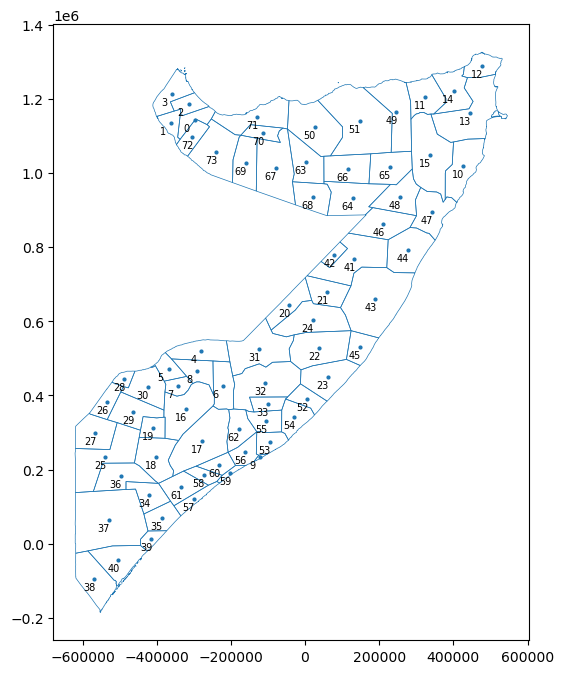

In [10]:
fig, ax = plt.subplots(1, figsize=(8,8))
gdf_gadm.boundary.plot(ax=ax, linewidth=0.5)
gdf_gadm.set_geometry('centroid').plot(ax=ax, markersize=4)

for idx, row in gdf_gadm.iterrows():
    point = row['centroid']
    x = point.x
    y = point.y
    ax.annotate(
        idx, xy=(x,y), 
        color='k', 
        xycoords='data',
        xytext=(-8, -8), 
        textcoords='offset points', 
        fontsize=7
    )

## District matching


On district names...

From Wikipedia [Administrative divisions of Somalia](https://en.wikipedia.org/wiki/Administrative_divisions_of_Somalia):
- 72 districts (no source)

Individual District pages (e.g. [Gabiley District](https://en.wikipedia.org/wiki/Gabiley_District)) cite following source: [Districts of Somalia](https://www.statoids.com/yso.html) by [Statoids](https://www.statoids.com/statoids.html) website, which seems to be a personal website, although published a book [*Administrative Divisions of Countries*](https://openlibrary.org/books/OL8138355M/Administrative_Subdivisions_of_Countries).
- Shows district names along with [**HASC** geocodes](https://en.wikipedia.org/wiki/Geocode#Hierarchical_naming) (dated 1990).
- Cites as source related to the Somalia National Peace Conference, but link is broken.

The DTM data provides [OCHA **P-codes**](https://knowledge.base.unocha.org/wiki/spaces/imtoolbox/pages/222265609/P-codes).

Could not find an easily accessible mapping from HASC to P-codes.

There is a dataset named [*World Bank Global Administrative Divisions*](https://gee-community-catalog.org/projects/wb_gad/) which seems to in general have attributes to level 2 admin areas in both HASC and P-code.

### GADM data

In [94]:
# Match districts in DTM to GADM via least edit distance

from Levenshtein import distance as edit_distance

district_matches = {}

for district_name in districts_dtm :
    distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_gadm}
    # distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_wb}
    closest_match, d = min(distances_to_gadm_names.items(), key=lambda x : x[1])
    district_matches[district_name] = (closest_match, d)

print(district_matches)

{'Waajid': ('Wajid', 1), 'Bulo Burto': ('BuuloBurdo', 3), 'Diinsoor': ('Diinsoor', 0), 'Xudur': ('Xudur', 0), 'Garoowe': ('Garoowe', 0), 'Adan Yabaal': ('Qandala', 7), 'Balcad': ('Balcad', 0), 'Saakow': ('Saakow', 0), 'Qansax Dheere': ('QansaxDheere', 1), 'Qoryooley': ('Qoryooley', 0), 'Belet Weyne': ('BeledWeyn', 3), 'Baardheere': ('Baar-Dheere', 2), 'Baidoa': ('Badhan', 3), "Bu'Aale": ("Bu'aale", 1), 'Jalalaqsi': ('Jalalaqsi', 0), 'Jamaame': ('Jamaame', 0), 'Gaalkacyo': ('Gaalkacayo', 1), 'Afgooye': ('Afgooye', 0), 'Jowhar': ('Jawhar', 1), 'Ceel Dheer': ('CeelDheer', 1), 'Cabudwaaq': ('Caabudwaaq', 1), 'Luuq': ('Luuk', 1), 'Kismaayo': ('Kismaayo', 0), 'Rab Dhuure': ('RabDhuure', 1), 'Kurtunwaarey': ('Kuntuwaaray', 3), 'Cadale': ('Cadale', 0), 'Buur Hakaba': ('BuurXakaba', 2), 'Badhaadhe': ('Badhaadhe', 0), 'Ceel Barde': ('CeelBarde', 1), 'Ceel Buur': ('CeelBuur', 1), 'Garbahaarey': ('Garbahaaray', 1), 'Tayeeglow': ('Tiyeeglow', 1), 'Afmadow': ('Afmadow', 0), 'Dhuusamarreeb': ('Dhuusa

In [99]:
# Print closely matching names
close_matches = {name : match for name, match in district_matches.items() if match[1] <= 3}
print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_dtm):.0%}) DTM names have exact or close matches (0 <= d <= 3) in GADM:")
longest_name_length = len(max(close_matches.keys(), key=len))
for name, match in sorted(close_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 58 (82%) DTM names have exact or close matches (0 <= d <= 3) in GADM:
Diinsoor      --> Diinsoor        (d = 0)
Xudur         --> Xudur           (d = 0)
Garoowe       --> Garoowe         (d = 0)
Balcad        --> Balcad          (d = 0)
Saakow        --> Saakow          (d = 0)
Qoryooley     --> Qoryooley       (d = 0)
Jalalaqsi     --> Jalalaqsi       (d = 0)
Jamaame       --> Jamaame         (d = 0)
Afgooye       --> Afgooye         (d = 0)
Kismaayo      --> Kismaayo        (d = 0)
Cadale        --> Cadale          (d = 0)
Badhaadhe     --> Badhaadhe       (d = 0)
Afmadow       --> Afmadow         (d = 0)
Hobyo         --> Hobyo           (d = 0)
Marka         --> Marka           (d = 0)
Taleex        --> Taleex          (d = 0)
Jilib         --> Jilib           (d = 0)
Baraawe       --> Baraawe         (d = 0)
Xarardheere   --> Xarardheere     (d = 0)
Jariiban      --> Jariiban        (d = 0)
Ceerigaabo    --> Ceerigaabo      (d = 0)
Eyl           --> Eyl             (d = 

In [100]:
# Print poorly matching names
poor_matches = {name : match for name, match in district_matches.items() if match[1] > 3}
print(f"Total of {len(poor_matches)} ({len(poor_matches)/len(districts_dtm):.0%}) DTM names have no close matches in GADM (d > 3):")
longest_name_length = len(max(poor_matches.keys(), key=len))
for name, match in sorted(poor_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 13 (18%) DTM names have no close matches in GADM (d > 3):
Laas Caanood     --> Lascaanod       (d = 4)
Huriwaa          --> Burao           (d = 4)
Waaberi          --> Berbera         (d = 4)
Shibis           --> Jilib           (d = 4)
Wardhigley       --> Gabiley         (d = 5)
Dayniile         --> Burtinle        (d = 5)
Dharkenley       --> Burtinle        (d = 6)
Shangaani        --> Aadan           (d = 6)
Laasqoray        --> Gaalkacayo      (d = 6)
Adan Yabaal      --> Qandala         (d = 7)
Hawl Wadaag      --> Balcad          (d = 7)
Hamar Jabjab     --> Hargeysa        (d = 8)
Wadajir (Medina) --> Wajid           (d = 11)


### World Bank data

In [101]:
# Load WB Admin2 additional attributes
wb_admin2_attr_file = 'data/WB_Official_Boundaries_Admin2_additional_columns.csv'

df_wb = pd.read_csv(wb_admin2_attr_file)
df_wb

/var/folders/17/j4v928fn43lgly2gzf268j480000gn/T/ipykernel_98941/1275919431.py:4: DtypeWarning: Columns (3,11,12,20,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_wb = pd.read_csv(wb_admin2_attr_file)


,ADM2CD_c,HASC_0,HASC_1,HASC_2,GAUL_0,GAUL_1,GAUL_2,SOVEREIGN,NAM_1_GAUL,NAM_1_STAT,...,P_CODE_2,P_CODE_2_t,P_NAME_2,ADM2CD,ADM2CD_t,ADM2NM,P_DATE,SALB_DATE,P_CODE_2_c,P_CODE_1_c
0,CHN001006,CN,CN.AH,NaN,147295,898,12984,CHN,Anhui Sheng,Anhui,...,CN034070,NaN,Hefei,NaN,CHN001006,NaN,2020-09-10,NaN,CN034070,CN034
1,CHN001002,CN,CN.AH,NaN,147295,898,12986,CHN,Anhui Sheng,Anhui,...,CN034020,NaN,Bengbu,NaN,CHN001002,NaN,2020-09-10,NaN,CN034020,CN034
2,CHN001008,CN,CN.AH,NaN,147295,898,12987,CHN,Anhui Sheng,Anhui,...,CN034090,NaN,Huainan,NaN,CHN001008,NaN,2020-09-10,NaN,CN034090,CN034
3,CHN001007,CN,CN.AH,NaN,147295,898,12989,CHN,Anhui Sheng,Anhui,...,CN034080,NaN,Huaibei,NaN,CHN001007,NaN,2020-09-10,NaN,CN034080,CN034
4,CHN001012,CN,CN.AH,NaN,147295,898,12994,CHN,Anhui Sheng,Anhui,...,NaN,CN034002,NaN,NaN,CHN001012,NaN,2020-09-10,NaN,CN034002,CN034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39365,USA023075,US,US.MI,NaN,259,3236,0,USA,Michigan,Michigan,...,NaN,US1234075,NaN,NaN,USA023075,NaN,NaN,NaN,US1234075,US1234
39366,USA050017,US,US.WI,NaN,259,3263,0,USA,Wisconsin,Wisconsin,...,NaN,US3050019,NaN,NaN,USA050017,NaN,NaN,NaN,US3050019,US3050
39367,USA050019,US,US.WI,NaN,259,3263,0,USA,Wisconsin,Wisconsin,...,NaN,US3050021,NaN,NaN,USA050019,NaN,NaN,NaN,US3050021,US3050
39368,WLF001001,WF,NaN,NaN,266,3392,32677,FRA,Administrative unit not available,NaN,...,NaN,WF01001,NaN,NaN,WLF001001,NaN,NaN,NaN,WF01001,WF01


In [103]:
# Filter to Somalia entries
df_wb_som = df_wb[df_wb['HASC_0'] == 'SO']
df_wb_som

,ADM2CD_c,HASC_0,HASC_1,HASC_2,GAUL_0,GAUL_1,GAUL_2,SOVEREIGN,NAM_1_GAUL,NAM_1_STAT,...,P_CODE_2,P_CODE_2_t,P_NAME_2,ADM2CD,ADM2CD_t,ADM2NM,P_DATE,SALB_DATE,P_CODE_2_c,P_CODE_1_c
6522,SOM001001,SO,SO.AW,NaN,226,2688,25653,SOM,Awdal,Awdal,...,SO1102,NaN,Baki,NaN,SOM001001,NaN,1984-06-23,NaN,SO1102,SO11
6523,SOM001002,SO,SO.AW,NaN,226,2688,25654,SOM,Awdal,Awdal,...,SO1101,NaN,Borama,NaN,SOM001002,NaN,1984-06-23,NaN,SO1101,SO11
6524,SOM001003,SO,SO.AW,NaN,226,2688,25655,SOM,Awdal,Awdal,...,SO1103,NaN,Lughaye,NaN,SOM001003,NaN,1984-06-23,NaN,SO1103,SO11
6525,SOM001004,SO,SO.AW,NaN,226,2688,25656,SOM,Awdal,Awdal,...,SO1104,NaN,Zeylac,NaN,SOM001004,NaN,1984-06-23,NaN,SO1104,SO11
6526,SOM002001,SO,SO.BK,NaN,226,2689,25657,SOM,Bakool,Bakool,...,SO2502,NaN,Ceel Barde,NaN,SOM002001,NaN,1984-06-23,NaN,SO2502,SO25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,SOM010003,SO,SO.JH,NaN,226,2696,25689,SOM,Juba Hoose,Jubbada Hoose,...,SO2804,NaN,Jamaame,NaN,SOM010003,NaN,1984-06-23,NaN,SO2804,SO28
8871,SOM010004,SO,SO.JH,NaN,226,2696,25690,SOM,Juba Hoose,Jubbada Hoose,...,SO2801,NaN,Kismaayo,NaN,SOM010004,NaN,1984-06-23,NaN,SO2801,SO28
8872,SOM015002,SO,SO.SH,NaN,226,2697,25692,SOM,Shabelle Hoose,Shabeellaha Hoose,...,SO2303,NaN,Baraawe,NaN,SOM015002,NaN,1984-06-23,NaN,SO2303,SO23
8873,SOM015003,SO,SO.SH,NaN,226,2697,25693,SOM,Shabelle Hoose,Shabeellaha Hoose,...,SO2304,NaN,Kurtunwaarey,NaN,SOM015003,NaN,1984-06-23,NaN,SO2304,SO23


Matches the number of districts in GADM data

In [104]:
df_wb_som.HASC_2.unique()

array([nan], dtype=object)

No HASC admin level 2 codes....

In [107]:
# Extract district names
districts_wb = df_wb_som.P_NAME_2[df_wb_som.P_NAME_2.notnull()].tolist()
districts_wb

['Baki',
 'Borama',
 'Lughaye',
 'Zeylac',
 'Ceel Barde',
 'Rab Dhuure',
 'Tayeeglow',
 'Waajid',
 'Xudur',
 'Bandarbeyla',
 'Bossaso',
 'Caluula',
 'Iskushuban',
 'Qandala',
 'Qardho',
 'Cabudwaaq',
 'Cadaado',
 'Ceel Buur',
 'Ceel Dheer',
 'Dhuusamarreeb',
 'Doolow',
 'Luuq',
 'Belet Weyne',
 'Bulo Burto',
 'Jalalaqsi',
 'Gaalkacyo',
 'Galdogob',
 'Hobyo',
 'Jariiban',
 'Xarardheere',
 'Burtinle',
 'Eyl',
 'Garoowe',
 'Laasqoray',
 'Ceel Afweyn',
 'Ceerigaabo',
 'Adan Yabaal',
 'Balcad',
 'Cadale',
 'Jowhar',
 'Afgooye',
 'Marka',
 'Qoryooley',
 'Wanla Weyn',
 'Caynabo',
 'Laas Caanood',
 'Taleex',
 'Xudun',
 'Burco',
 'Buuhoodle',
 'Owdweyne',
 'Sheikh',
 'Berbera',
 'Gebiley',
 'Hargeysa',
 'Baydhaba',
 'Buur Hakaba',
 'Diinsoor',
 'Qansax Dheere',
 'Baardheere',
 'Belet Xaawo',
 'Ceel Waaq',
 'Garbahaarey',
 "Bu'aale",
 'Jilib',
 'Saakow',
 'Afmadow',
 'Badhaadhe',
 'Jamaame',
 'Kismaayo',
 'Baraawe',
 'Kurtunwaarey',
 'Sablaale']

In [108]:
len(districts_wb)

73

In [24]:
sum(df_wb_som.P_NAME_2.isna())

1

Not sure what the one NaN entry is about

In [109]:
# Match districts in WB to GADM via least edit distance (by name)

from Levenshtein import distance as edit_distance

district_matches_wb = {}

for district_name in districts_wb :
    distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_gadm}
    # distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_dtm}
    closest_match, d = min(distances_to_gadm_names.items(), key=lambda x : x[1])
    district_matches_wb[district_name] = (closest_match, d)

print(district_matches_wb)

{'Baki': ('Baki', 0), 'Borama': ('Boorama', 1), 'Lughaye': ('Lughaya', 1), 'Zeylac': ('Zeylac', 0), 'Ceel Barde': ('CeelBarde', 1), 'Rab Dhuure': ('RabDhuure', 1), 'Tayeeglow': ('Tiyeeglow', 1), 'Waajid': ('Wajid', 1), 'Xudur': ('Xudur', 0), 'Bandarbeyla': ('Bander-Beyla', 3), 'Bossaso': ('Bosaaso', 1), 'Caluula': ('Calawla', 2), 'Iskushuban': ('Iskushuban', 0), 'Qandala': ('Qandala', 0), 'Qardho': ('Qardho', 0), 'Cabudwaaq': ('Caabudwaaq', 1), 'Cadaado': ('Cadaado', 0), 'Ceel Buur': ('CeelBuur', 1), 'Ceel Dheer': ('CeelDheer', 1), 'Dhuusamarreeb': ('Dhuusamareeb', 1), 'Doolow': ('Dolow', 1), 'Luuq': ('Luuk', 1), 'Belet Weyne': ('BeledWeyn', 3), 'Bulo Burto': ('BuuloBurdo', 3), 'Jalalaqsi': ('Jalalaqsi', 0), 'Gaalkacyo': ('Gaalkacayo', 1), 'Galdogob': ('Goldogob', 1), 'Hobyo': ('Hobyo', 0), 'Jariiban': ('Jariiban', 0), 'Xarardheere': ('Xarardheere', 0), 'Burtinle': ('Burtinle', 0), 'Eyl': ('Eyl', 0), 'Garoowe': ('Garoowe', 0), 'Laasqoray': ('Gaalkacayo', 6), 'Ceel Afweyn': ('Ceel-Afwei

In [110]:
# Print closely matching names
close_matches = {name : match for name, match in district_matches_wb.items() if 0 <= match[1] <= 3}
print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_wb):.0%}) WB names have exact or close matches (0 <= d <= 3) in DTM:")
longest_name_length = len(max(close_matches.keys(), key=len))
for name, match in sorted(close_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 70 (96%) WB names have exact or close matches (0 <= d <= 3) in DTM:
Baki          --> Baki            (d = 0)
Zeylac        --> Zeylac          (d = 0)
Xudur         --> Xudur           (d = 0)
Iskushuban    --> Iskushuban      (d = 0)
Qandala       --> Qandala         (d = 0)
Qardho        --> Qardho          (d = 0)
Cadaado       --> Cadaado         (d = 0)
Jalalaqsi     --> Jalalaqsi       (d = 0)
Hobyo         --> Hobyo           (d = 0)
Jariiban      --> Jariiban        (d = 0)
Xarardheere   --> Xarardheere     (d = 0)
Burtinle      --> Burtinle        (d = 0)
Eyl           --> Eyl             (d = 0)
Garoowe       --> Garoowe         (d = 0)
Ceerigaabo    --> Ceerigaabo      (d = 0)
Balcad        --> Balcad          (d = 0)
Cadale        --> Cadale          (d = 0)
Afgooye       --> Afgooye         (d = 0)
Marka         --> Marka           (d = 0)
Qoryooley     --> Qoryooley       (d = 0)
Caynabo       --> Caynabo         (d = 0)
Taleex        --> Taleex          (d = 0)

In [112]:
# Print poorly matching names
poor_matches = {name : match for name, match in district_matches_wb.items() if match[1] > 3}
print(f"Total of {len(poor_matches)} ({len(poor_matches)/len(districts_wb):.0%}) names have no close matches in DTM (d > 3):")
longest_name_length = len(max(poor_matches.keys(), key=len))
for name, match in sorted(poor_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 3 (4%) names have no close matches in DTM (d > 3):
Laas Caanood --> Lascaanod       (d = 4)
Laasqoray    --> Gaalkacayo      (d = 6)
Adan Yabaal  --> Qandala         (d = 7)


Now we have the P-code of districts connected to a name that closely matches the name in GADM. We can connect these P-codes to the names in our data.

Then we basically have the mapping GADM names (& geometry) -> WB names -> WB Pcodes -> DTM Pcodes -> DTM names

The problem is that the DTM data doesn't have Pcodes for origin districts. Perhaps this could be solved by the data from the DTM api?

(BTW we could also just use the geo data from the world bank, instead of GADM altogether. Although that might not solve our problems.)

# Flows

In [33]:
g_all_weeks = nx.DiGraph()
g_all_weeks.add_nodes_from(districts_dtm)

for origin in districts_dtm :
    points_origin = df_dtm[df_dtm['Origin_District_country'] == origin]
    # for destination in districts_dtm :
    for destination in destination_districts :
        # print(points_origin['District Name'].unique())
        if destination in points_origin['District Name'].values :  # If this district was a destination for this origin
            points_origin_dest = points_origin[points_origin['District Name'] == destination]
            total_arrivals = points_origin_dest['Total new arrivals since last week'].sum()

            g_all_weeks.add_edge(origin, destination, weight=total_arrivals)

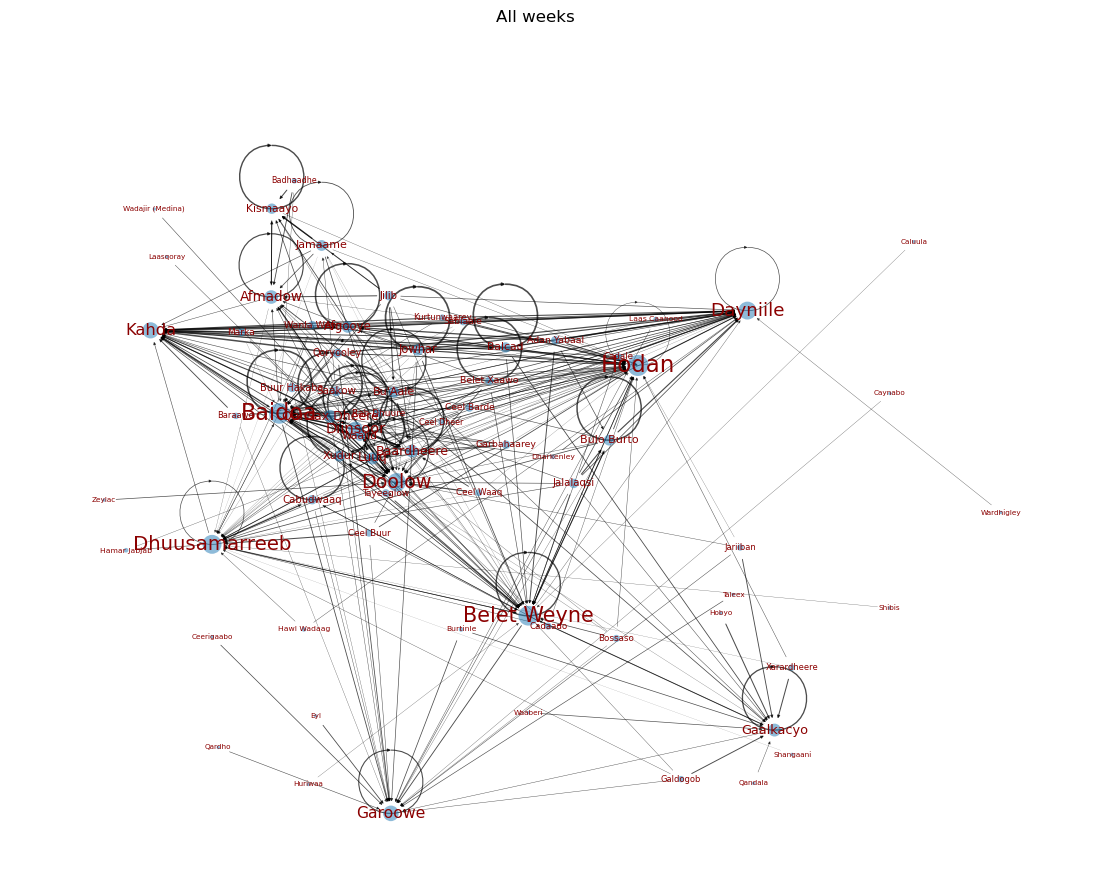

In [39]:
pos_params = dict(
    weight='weight', 
    method='force', 
    # gravity=1,
    k=2,
    iterations=50,
    center=(0,0)
)

def plot_flow_graph(g, ax, pos=None, 
                    with_labels=True, 
                    no_self_loops=False,
                    node_sizes=None,
                    edge_colors=None
                    ) :
    if pos is None :
        pos = nx.spring_layout(g, **pos_params)
        # pos = nx.random_layout(g)

    if node_sizes is None : node_sizes = [1 + g.degree(n) * 5 for n in g.nodes()]
    nx.draw_networkx_nodes(g, pos=pos, ax=ax,
                        node_size=node_sizes, 
                        linewidths=0,
                        alpha=0.5
                        )
    
    if no_self_loops :
        edge_widths = [np.log(d['weight'])/8 if u != v else 0 for (u,v,d) in g.edges(data=True)]
    else :
        edge_widths = [np.log(d['weight'])/8 for (u,v,d) in g.edges(data=True)]
    if edge_colors is None : edge_colors = 'Black'
    nx.draw_networkx_edges(g, pos=pos, ax=ax,
                        width=edge_widths, 
                        edge_color=edge_colors,
                        arrowsize=4,
                        alpha=0.7
                        )
    
    if with_labels :
        font_sizes = {n : 5 + g.degree(n)/4 for n in g.nodes()}
        nx.draw_networkx_labels(g, pos=pos, ax=ax,
                                font_size=font_sizes,
                                font_color='DarkRed'
                                )
    
    ax.axis('off')
    
fig, ax = plt.subplots(1, figsize=(14,10))

pos_all_weeks = nx.spring_layout(g_all_weeks, seed=10, **pos_params)
# pos_all_weeks = nx.random_layout(g_all_weeks)
# pos_all_weeks = nx.circular_layout(g_all_weeks)

node_sizes_all_weeks = [1 + g_all_weeks.degree(n) * 5 for n in g_all_weeks.nodes()]
plot_flow_graph(g_all_weeks, ax, pos=pos_all_weeks, node_sizes=node_sizes_all_weeks)

xlim_all_weeks = ax.get_xlim()
ylim_all_weeks = ax.get_ylim()

fig.suptitle('All weeks');

In [42]:
# Networks per week

g_per_week = []
weeks = sorted(df_dtm['Data Collection Week'].unique())

for i, week in enumerate(weeks) :
    g = nx.DiGraph()
    g.add_nodes_from(districts_dtm)

    df_week = df_dtm[df_dtm['Data Collection Week'] == week]
    for origin in districts_dtm :
        points_origin = df_week[df_week['Origin_District_country'] == origin]
        for destination in destination_districts :
            if destination in points_origin['District Name'].values :
                points_origin_dest = points_origin[points_origin['District Name'] == destination]
                total_arrivals = points_origin_dest['Total new arrivals since last week'].sum()

                g.add_edge(origin, destination, weight=total_arrivals)

    g_per_week.append(g)

g_per_week[0].nodes()

NodeView(('Waajid', 'Bulo Burto', 'Diinsoor', 'Xudur', 'Garoowe', 'Adan Yabaal', 'Balcad', 'Saakow', 'Qansax Dheere', 'Qoryooley', 'Belet Weyne', 'Baardheere', 'Baidoa', "Bu'Aale", 'Jalalaqsi', 'Jamaame', 'Gaalkacyo', 'Afgooye', 'Jowhar', 'Ceel Dheer', 'Cabudwaaq', 'Luuq', 'Kismaayo', 'Rab Dhuure', 'Kurtunwaarey', 'Cadale', 'Buur Hakaba', 'Badhaadhe', 'Ceel Barde', 'Ceel Buur', 'Garbahaarey', 'Tayeeglow', 'Afmadow', 'Dhuusamarreeb', 'Belet Xaawo', 'Dharkenley', 'Hobyo', 'Marka', 'Taleex', 'Jilib', 'Ceel Waaq', 'Bossaso', 'Wanla Weyn', 'Baraawe', 'Doolow', 'Sablaale', 'Hodan', 'Xarardheere', 'Wardhigley', 'Hamar Jabjab', 'Jariiban', 'Ceerigaabo', 'Dayniile', 'Galdogob', 'Kahda', 'Eyl', 'Shangaani', 'Hawl Wadaag', 'Qardho', 'Cadaado', 'Laasqoray', 'Burtinle', 'Laas Caanood', 'Huriwaa', 'Qandala', 'Zeylac', 'Waaberi', 'Caluula', 'Shibis', 'Wadajir (Medina)', 'Caynabo'))

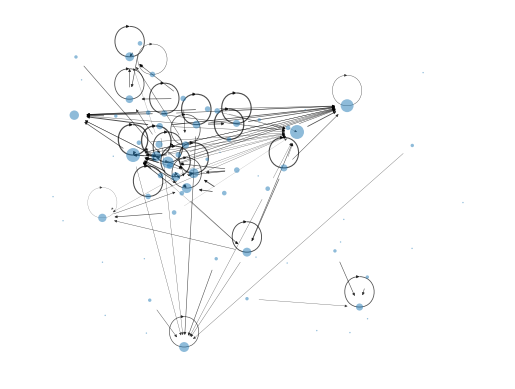

In [43]:
ax = plt.subplot()
plot_flow_graph(g_per_week[0], ax, pos=pos_all_weeks, with_labels=False)
ax.set_xlim(xlim_all_weeks)
ax.set_ylim(ylim_all_weeks);

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

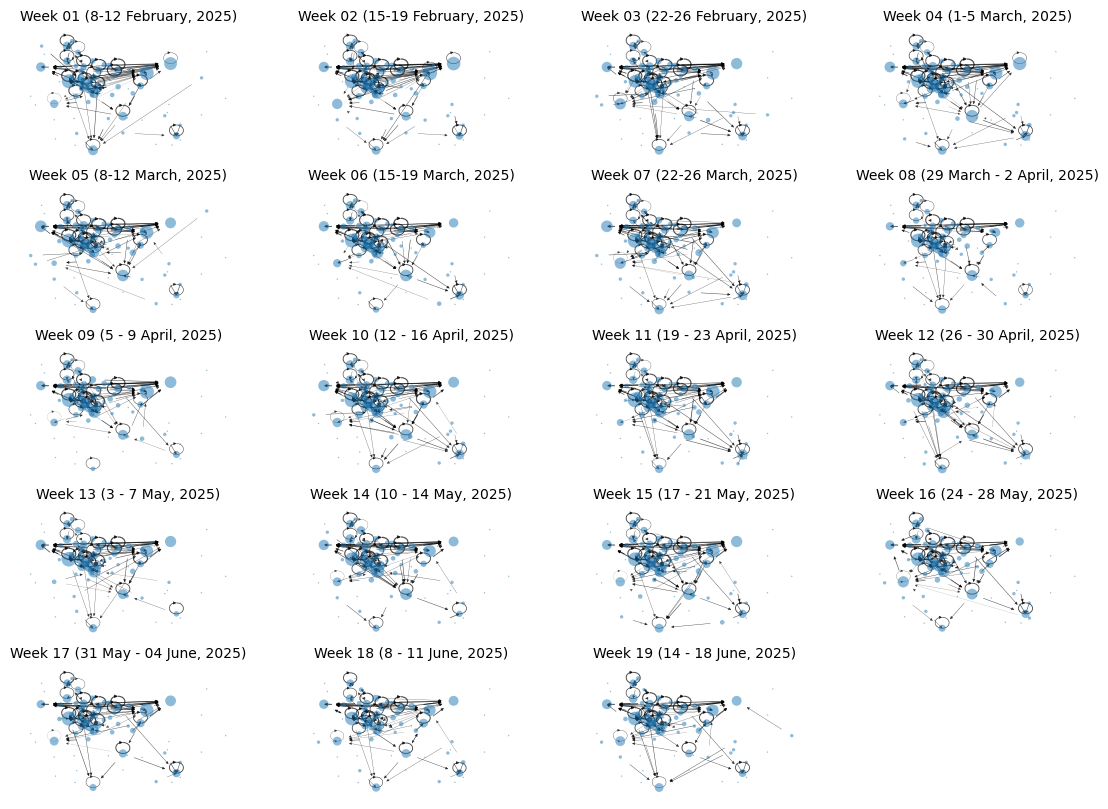

In [44]:
fig, axs = plt.subplots(len(weeks) // 4 + 1, 4, figsize=(14,10))
axs_flat = axs.flatten()

for i, g in enumerate(g_per_week) :
    ax = axs_flat[i]
    plot_flow_graph(g, ax, pos=pos_all_weeks, with_labels=False)
    ax.set_title(weeks[i], size=10)
    ax.set(xlim=xlim_all_weeks, ylim=ylim_all_weeks)

axs_flat[-1].axis('off')

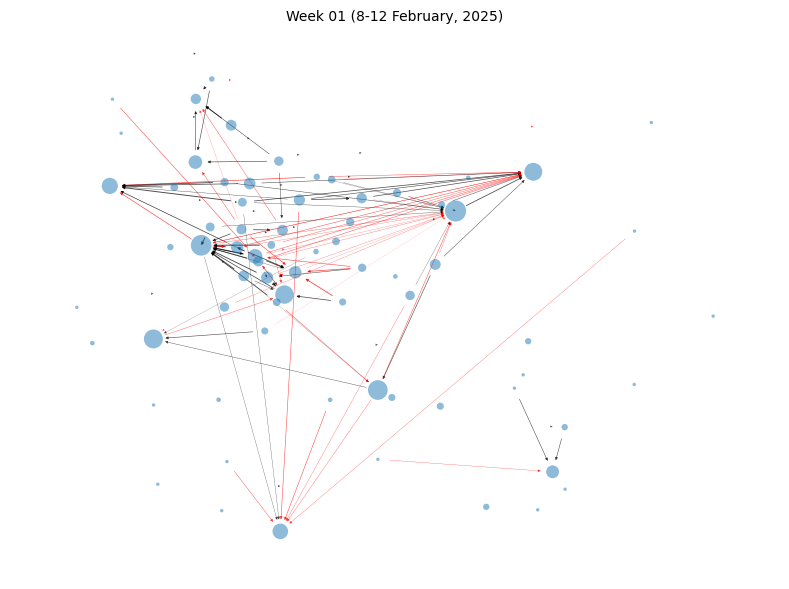

In [45]:
from matplotlib import animation

fig, ax = plt.subplots(1, figsize=(8,6), layout='tight')

def update(i_frame):
    ax.clear()

    g = g_per_week[i_frame]
    try :
        g_prev = g_per_week[i_frame-1]
        edge_colors = ['red' if e not in g_prev.edges() else 'black' for e in g.edges()]
    except IndexError :
        edge_colors = None

    plot_flow_graph(g, ax, pos=pos_all_weeks, with_labels=False, node_sizes=node_sizes_all_weeks, edge_colors=edge_colors, no_self_loops=True)

    ax.set_title(weeks[i_frame], size=10)

    ax.set(xlim=xlim_all_weeks, ylim=ylim_all_weeks)

ani = animation.FuncAnimation(fig, update, frames=len(weeks), interval=1000, repeat=True)

# plt.show()
ani.save('figs/weekly_flows_district.gif')

# DTM api

The DTM has an API that you can use to get data by country, admin level, timeframe, etc... 

While it gives us IDPs that move to a given district, unfortunately (as you see below) it only gives the region (admin level 1) as origin, so we could not use it to analyze flows on the level of districts.

DTM API [homepage](https://dtm.iom.int/data-and-analysis/dtm-api)

PyPI [package](https://pypi.org/project/dtmapi/) and [documentation](https://dtmapi.readthedocs.io/en/latest/dtmapi.html#dtmapi.DTMApi)

[User profile](https://dtm-apim-portal.iom.int/profile)

In [48]:
from dtmapi import DTMApi

with open('dtm_api_key.txt', 'r') as f:
    api_key = f.read()

# Instantiate the API client with your subscription key.
api = DTMApi(subscription_key=api_key)

In [50]:
all_country_list = api.get_all_countries()
all_country_list.head(10)

,admin0Name,admin0Pcode
0,Afghanistan,AFG
1,Antigua and Barbuda,ATG
2,Bahamas (the),BHS
3,Benin,BEN
4,Bolivia (Plurinational State of),BOL
5,Burkina Faso,BFA
6,Burundi,BDI
7,Cameroon,CMR
8,Central African Republic,CAF
9,Chad,TCD


In [51]:
all_country_list[all_country_list['admin0Name'] == 'Somalia']

,admin0Name,admin0Pcode
41,Somalia,SOM


In [52]:
len(all_country_list)

53

In [53]:
all_operation_list = api.get_all_operations()
all_operation_list.head()


,operation,operationStatus,admin0Name,admin0Pcode
0,Aceh earthquake,Inactive,Indonesia,IDN
1,Armed Clashes in Sudan,Active,Sudan,SDN
2,Armed Clashes in Sudan (Monthly),Active,Sudan,SDN
3,Armed Clashes in Sudan (Overview),Active,Sudan,SDN
4,Arrivals in Armenia,Inactive,Republic of Armenia,ARM


In [54]:
all_operation_list[all_operation_list['admin0Name'] == 'Somalia']

,operation,operationStatus,admin0Name,admin0Pcode
92,Somalia - Countrywide Monitoring,Active,Somalia,SOM
93,Somalia displacement,Active,Somalia,SOM


In [55]:
idp_admin2_data = api.get_idp_admin2_data(Operation="Somalia displacement", CountryName='Somalia')
idp_admin2_data.sort_values(by=['reportingDate'], ascending=False)

,id,operation,admin0Name,admin0Pcode,admin1Name,admin1Pcode,admin2Name,admin2Pcode,numPresentIdpInd,reportingDate,yearReportingDate,monthReportingDate,roundNumber,displacementReason,numberMales,numberFemales,idpOriginAdmin1Name,idpOriginAdmin1Pcode,assessmentType
585,34090,Somalia displacement,Somalia,SOM,Bari,SOM16,Qandala,SOM1605,44550,2017-11-30T00:00:00,2017,11,15,Conflict; Natural disaster,None,None,Not available,Not available,BA
539,101943,Somalia displacement,Somalia,SOM,Gedo,SOM26,Luuq,SOM2606,30036,2017-11-30T00:00:00,2017,11,15,Conflict; Natural disaster,None,None,Not available,Not available,BA
553,87734,Somalia displacement,Somalia,SOM,Galgaduud,SOM19,Dhuusamarreeb,SOM1901,10394,2017-11-30T00:00:00,2017,11,15,Conflict; Natural disaster,None,None,Not available,Not available,BA
552,87602,Somalia displacement,Somalia,SOM,Nugaal,SOM17,Eyl,SOM1703,1512,2017-11-30T00:00:00,2017,11,15,Conflict; Natural disaster,None,None,Not available,Not available,BA
551,86780,Somalia displacement,Somalia,SOM,Hiraan,SOM20,Belet Weyne,SOM2001,105630,2017-11-30T00:00:00,2017,11,15,Conflict; Natural disaster,None,None,Not available,Not available,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,18477,Somalia displacement,Somalia,SOM,Hiraan,SOM20,Belet Weyne,SOM2001,132204,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,None,None,Not available,Not available,BA
1,127596,Somalia displacement,Somalia,SOM,Awdal,SOM11,Borama,SOM1101,14130,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,None,None,Not available,Not available,BA
5,22658,Somalia displacement,Somalia,SOM,Shabelle Dhexe,SOM21,Jowhar,SOM2101,87786,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,None,None,Not available,Not available,BA
6,37137,Somalia displacement,Somalia,SOM,Shabelle Dhexe,SOM21,Balcad,SOM2103,27282,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,None,None,Not available,Not available,BA


In [65]:
idp_admin2_data = api.get_idp_admin2_data(CountryName='Somalia')
idp_admin2_data.sort_values(by=['reportingDate'], ascending=False)

,id,operation,admin0Name,admin0Pcode,admin1Name,admin1Pcode,admin2Name,admin2Pcode,numPresentIdpInd,reportingDate,yearReportingDate,monthReportingDate,roundNumber,displacementReason,numberMales,numberFemales,idpOriginAdmin1Name,idpOriginAdmin1Pcode,assessmentType
1251,56218,Somalia - Countrywide Monitoring,Somalia,SOM,Mudug,SOM18,Gaalkacyo,SOM1801,2676,2024-09-30T00:00:00,2024,9,3,Other reason,1177.0,1499.0,Bay,SOM24,BA
1088,89366,Somalia - Countrywide Monitoring,Somalia,SOM,Shabelle Dhexe,SOM21,Adan Yabaal,SOM2102,240,2024-09-30T00:00:00,2024,9,3,Conflict,85.0,155.0,Galgaduud,SOM19,BA
1086,86981,Somalia - Countrywide Monitoring,Somalia,SOM,Banadir,SOM22,Banadir,SOM2201,4170,2024-09-30T00:00:00,2024,9,3,Conflict,1893.0,2277.0,Sool,SOM14,BA
1085,87522,Somalia - Countrywide Monitoring,Somalia,SOM,Banadir,SOM22,Banadir,SOM2201,372,2024-09-30T00:00:00,2024,9,3,Other reason,169.0,203.0,Banadir,SOM22,BA
1084,86848,Somalia - Countrywide Monitoring,Somalia,SOM,Shabelle Dhexe,SOM21,Jowhar,SOM2101,13900,2024-09-30T00:00:00,2024,9,3,Natural disaster,6526.0,7374.0,Shabelle Dhexe,SOM21,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,18477,Somalia displacement,Somalia,SOM,Hiraan,SOM20,Belet Weyne,SOM2001,132204,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,NaN,NaN,Not available,Not available,BA
1,127596,Somalia displacement,Somalia,SOM,Awdal,SOM11,Borama,SOM1101,14130,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,NaN,NaN,Not available,Not available,BA
5,22658,Somalia displacement,Somalia,SOM,Shabelle Dhexe,SOM21,Jowhar,SOM2101,87786,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,NaN,NaN,Not available,Not available,BA
6,37137,Somalia displacement,Somalia,SOM,Shabelle Dhexe,SOM21,Balcad,SOM2103,27282,2016-06-01T00:00:00,2016,6,1,Conflict; Natural disaster,NaN,NaN,Not available,Not available,BA


^ IDP numbers are reported only based on admin 1 (regions) as origin.

In [66]:
admin2_name_and_pcode = idp_admin2_data[['admin2Name', 'admin2Pcode']]
admin2_name_and_pcode

,admin2Name,admin2Pcode
0,Kismaayo,SOM2801
1,Borama,SOM1101
2,Afmadow,SOM2802
3,Belet Weyne,SOM2001
4,Doolow,SOM2605
...,...,...
1247,Baardheere,SOM2602
1248,Cabudwaaq,SOM1902
1249,Galdogob,SOM1802
1250,Gaalkacyo,SOM1801


In [86]:
districts_api = admin2_name_and_pcode['admin2Name'].unique()
len(districts_api)

70

In [87]:
districts_api.sort()
print(districts_api)

['Adan Yabaal' 'Afgooye' 'Afmadow' 'Baardheere' 'Badhaadhe' 'Baki'
 'Balcad' 'Banadir' 'Baraawe' 'Baydhaba' 'Belet Weyne' 'Belet Xaawo'
 'Berbera' 'Borama' 'Bossaso' "Bu'Aale" 'Bulo Burto' 'Burco' 'Burtinle'
 'Buuhoodle' 'Buur Hakaba' 'Cabudwaaq' 'Cadaado' 'Cadale' 'Caluula'
 'Caynabo' 'Ceel Afweyn' 'Ceel Barde' 'Ceel Waaq' 'Ceerigaabo'
 'Dhuusamarreeb' 'Diinsoor' 'Doolow' 'Eyl' 'Gaalkacyo' 'Galdogob'
 'Garbahaarey' 'Garoowe' 'Gebiley' 'Hargeysa' 'Hobyo' 'Iskushuban'
 'Jalalaqsi' 'Jamaame' 'Jariiban' 'Jilib' 'Jowhar' 'Kismaayo'
 'Kurtunwaarey' 'Laas Caanood' 'Laasqoray' 'Lughaye' 'Luuq' 'Marka'
 'Owdweyne' 'Qandala' 'Qansax Dheere' 'Qardho' 'Qoryooley' 'Rab Dhuure'
 'Saakow' 'Sheikh' 'Taleex' 'Tayeeglow' 'Waajid' 'Wanla Weyn'
 'Xarardheere' 'Xudun' 'Xudur' 'Zeylac']


In [88]:
d = np.array(districts_dtm)
d.sort()
print(d)

['Adan Yabaal' 'Afgooye' 'Afmadow' 'Baardheere' 'Badhaadhe' 'Baidoa'
 'Balcad' 'Baraawe' 'Belet Weyne' 'Belet Xaawo' 'Bossaso' "Bu'Aale"
 'Bulo Burto' 'Burtinle' 'Buur Hakaba' 'Cabudwaaq' 'Cadaado' 'Cadale'
 'Caluula' 'Caynabo' 'Ceel Barde' 'Ceel Buur' 'Ceel Dheer' 'Ceel Waaq'
 'Ceerigaabo' 'Dayniile' 'Dharkenley' 'Dhuusamarreeb' 'Diinsoor' 'Doolow'
 'Eyl' 'Gaalkacyo' 'Galdogob' 'Garbahaarey' 'Garoowe' 'Hamar Jabjab'
 'Hawl Wadaag' 'Hobyo' 'Hodan' 'Huriwaa' 'Jalalaqsi' 'Jamaame' 'Jariiban'
 'Jilib' 'Jowhar' 'Kahda' 'Kismaayo' 'Kurtunwaarey' 'Laas Caanood'
 'Laasqoray' 'Luuq' 'Marka' 'Qandala' 'Qansax Dheere' 'Qardho' 'Qoryooley'
 'Rab Dhuure' 'Saakow' 'Sablaale' 'Shangaani' 'Shibis' 'Taleex'
 'Tayeeglow' 'Waaberi' 'Waajid' 'Wadajir (Medina)' 'Wanla Weyn'
 'Wardhigley' 'Xarardheere' 'Xudur' 'Zeylac']


In [91]:
# Match districts in DTM from API to dataset

from Levenshtein import distance as edit_distance

district_matches_api = {}

for district_name in districts_api :
    distances_to_dtm_names = {x : edit_distance(district_name, x) for x in districts_dtm}
    closest_match, d = min(distances_to_dtm_names.items(), key=lambda x : x[1])
    district_matches_api[district_name] = (closest_match, d)

# Print all matches
# close_matches = {name : match for name, match in district_matches_wb.items() if 0 <= match[1] <= 3}
# print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_wb):.0%}) WB names have exact or close matches (0 <= d <= 3) in DTM:")
longest_name_length = len(max(district_matches_api.keys(), key=len))
for name, match in sorted(district_matches_api.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Adan Yabaal   --> Adan Yabaal     (d = 0)
Afgooye       --> Afgooye         (d = 0)
Afmadow       --> Afmadow         (d = 0)
Baardheere    --> Baardheere      (d = 0)
Badhaadhe     --> Badhaadhe       (d = 0)
Balcad        --> Balcad          (d = 0)
Baraawe       --> Baraawe         (d = 0)
Belet Weyne   --> Belet Weyne     (d = 0)
Belet Xaawo   --> Belet Xaawo     (d = 0)
Bossaso       --> Bossaso         (d = 0)
Bu'Aale       --> Bu'Aale         (d = 0)
Bulo Burto    --> Bulo Burto      (d = 0)
Burtinle      --> Burtinle        (d = 0)
Buur Hakaba   --> Buur Hakaba     (d = 0)
Cabudwaaq     --> Cabudwaaq       (d = 0)
Cadaado       --> Cadaado         (d = 0)
Cadale        --> Cadale          (d = 0)
Caluula       --> Caluula         (d = 0)
Caynabo       --> Caynabo         (d = 0)
Ceel Barde    --> Ceel Barde      (d = 0)
Ceel Waaq     --> Ceel Waaq       (d = 0)
Ceerigaabo    --> Ceerigaabo      (d = 0)
Dhuusamarreeb --> Dhuusamarreeb   (d = 0)
Diinsoor      --> Diinsoor        